<a href="https://colab.research.google.com/github/CipherBliss/Amazon-clone-/blob/main/AI_Based_Mental_Health_Monitoring_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv("/content/Mental Health Dataset.csv", header=0)
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [8]:
df.shape

(292364, 17)

In [9]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [11]:
df.isnull().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5202
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [12]:
df = df.drop(columns=["Timestamp"])
df["self_employed"] = df["self_employed"].fillna("No")

In [13]:
df

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


In [14]:
df.isnull().sum()

,0
Gender,0
Country,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0
Mental_Health_History,0


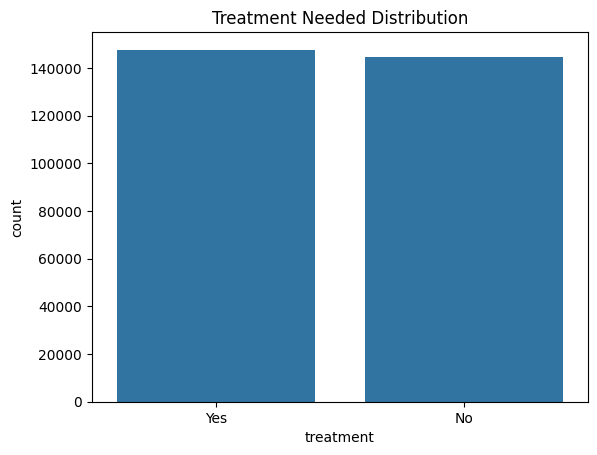

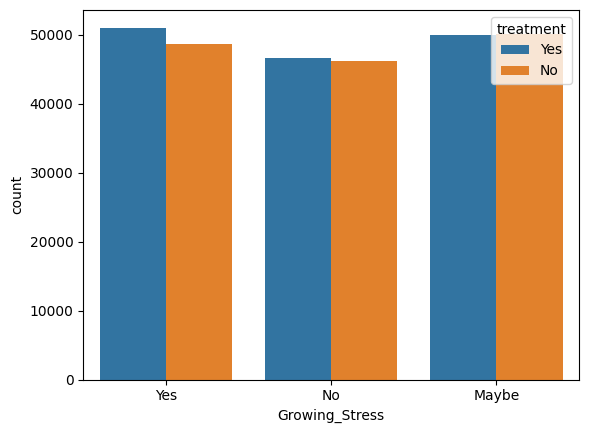

In [15]:
# Target balance
sns.countplot(x="treatment", data=df)
plt.title("Treatment Needed Distribution")
plt.show()

# Example: stress vs treatment
sns.countplot(x="Growing_Stress", hue="treatment", data=df)
plt.show()

In [16]:
target = "treatment"
X = df.drop(columns=[target])
y = df[target]

In [17]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
X_encoded = X.copy()
for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le

y_le = LabelEncoder()
y_encoded = y_le.fit_transform(y)   # Yes=1, No=0 (check with y_le.classes_)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(X_train.shape, X_test.shape)

(233891, 15) (58473, 15)


Logistic Regression Accuracy: 0.7033331623142305

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.68      0.70     28952
           1       0.70      0.72      0.71     29521

    accuracy                           0.70     58473
   macro avg       0.70      0.70      0.70     58473
weighted avg       0.70      0.70      0.70     58473



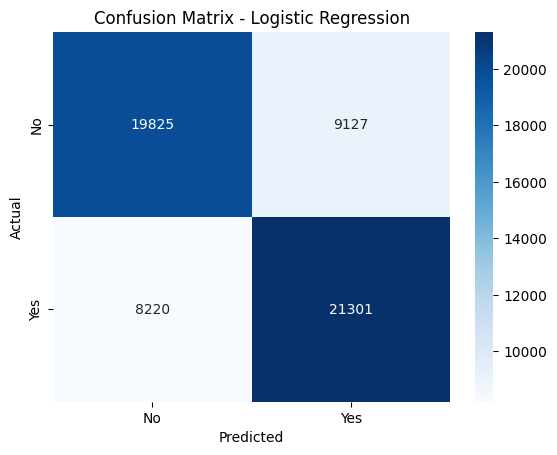

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_preds)
print("Logistic Regression Accuracy:", log_acc)
print("\nClassification Report:\n", classification_report(y_test, log_preds))

cm = confusion_matrix(y_test, log_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=y_le.classes_, yticklabels=y_le.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Accuracy: 0.7632924597677561

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.75     28952
           1       0.75      0.80      0.77     29521

    accuracy                           0.76     58473
   macro avg       0.76      0.76      0.76     58473
weighted avg       0.76      0.76      0.76     58473



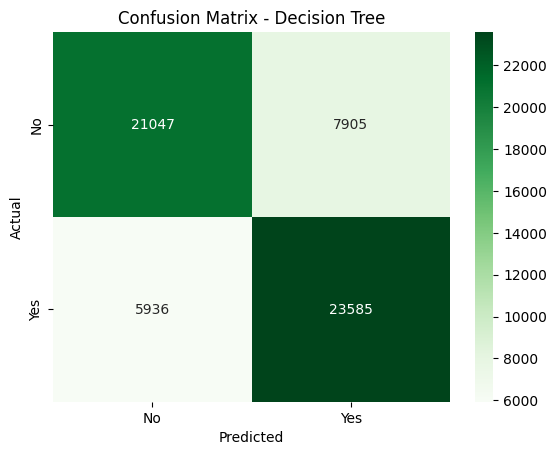

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_preds)
print("Decision Tree Accuracy:", dt_acc)
print("\nClassification Report:\n", classification_report(y_test, dt_preds))

cm = confusion_matrix(y_test, dt_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=y_le.classes_, yticklabels=y_le.classes_)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 0.7568963453217724

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.74     28952
           1       0.74      0.80      0.77     29521

    accuracy                           0.76     58473
   macro avg       0.76      0.76      0.76     58473
weighted avg       0.76      0.76      0.76     58473



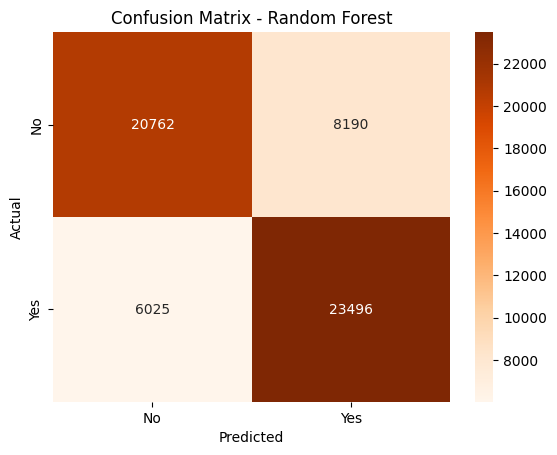

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=y_le.classes_, yticklabels=y_le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                 Model  Accuracy
1        Decision Tree  0.763292
2        Random Forest  0.756896
0  Logistic Regression  0.703333


/tmp/ipykernel_914/4112801409.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=comparison, palette="viridis")


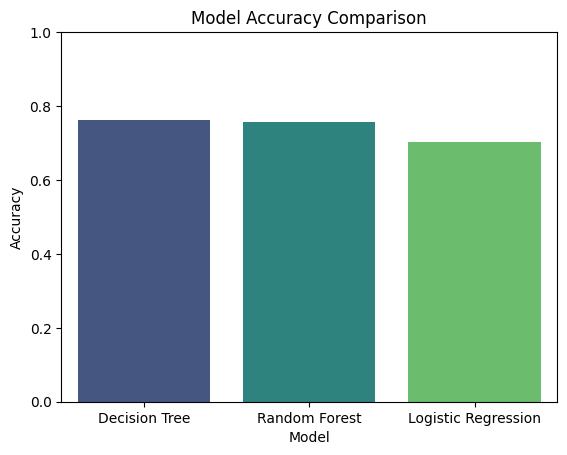


Best model: Decision Tree


In [22]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc]
}).sort_values("Accuracy", ascending=False)

print(comparison)

sns.barplot(x="Model", y="Accuracy", data=comparison, palette="viridis")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

best_model_name = comparison.iloc[0]["Model"]
best_model = {"Logistic Regression": log_model, "Decision Tree": dt_model, "Random Forest": rf_model}[best_model_name]
print("\nBest model:", best_model_name)

In [24]:
if best_model_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
    importances.sort_values().plot(kind="barh", figsize=(8,6))
    plt.title("Feature Importance")
    plt.show()

In [25]:
import joblib

joblib.dump(best_model, "mental_health_model.pkl")
joblib.dump(encoders, "feature_encoders.pkl")
joblib.dump(y_le, "target_encoder.pkl")
joblib.dump(list(X_encoded.columns), "feature_columns.pkl")

print("Saved: mental_health_model.pkl, feature_encoders.pkl, target_encoder.pkl, feature_columns.pkl")

Saved: mental_health_model.pkl, feature_encoders.pkl, target_encoder.pkl, feature_columns.pkl


In [26]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def analyze_journal_entry(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound <= -0.5:
        mood = "Highly Negative"
    elif compound <= -0.1:
        mood = "Negative"
    elif compound < 0.1:
        mood = "Neutral"
    elif compound < 0.5:
        mood = "Positive"
    else:
        mood = "Highly Positive"
    return mood, scores

# test
print(analyze_journal_entry("I feel so exhausted and hopeless lately, nothing feels worth it."))
print(analyze_journal_entry("I had a great day, feeling productive and calm."))

('Highly Negative', {'neg': 0.525, 'neu': 0.475, 'pos': 0.0, 'compound': -0.7732})
('Highly Positive', {'neg': 0.0, 'neu': 0.336, 'pos': 0.664, 'compound': 0.7845})


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [27]:
def combined_risk_assessment(ml_prediction, journal_mood):
    """
    ml_prediction: 'Yes'/'No' from the questionnaire model
    journal_mood: output of analyze_journal_entry
    """
    risk = "Low"
    if ml_prediction == "Yes" and journal_mood in ["Negative", "Highly Negative"]:
        risk = "High"
    elif ml_prediction == "Yes" or journal_mood in ["Negative", "Highly Negative"]:
        risk = "Moderate"
    return risk

In [32]:
!pip install -q streamlit
!pip install -q nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 76.9 MB/s eta 0:00:00


In [40]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

@st.cache_resource
def load_sentiment_analyzer():
    try:
        nltk.data.find('sentiment/vader_lexicon.zip')
    except LookupError:
        nltk.download('vader_lexicon')
    return SentimentIntensityAnalyzer()

sia = load_sentiment_analyzer()

@st.cache_resource
def load_ml_artifacts():
    model = joblib.load("mental_health_model.pkl")
    encoders = joblib.load("feature_encoders.pkl")
    target_encoder = joblib.load("target_encoder.pkl")
    feature_columns = joblib.load("feature_columns.pkl")
    return model, encoders, target_encoder, feature_columns

model, encoders, target_encoder, feature_columns = load_ml_artifacts()

st.set_page_config(page_title="AI Mental Health Monitor", page_icon="🧠", layout="centered")
st.title("🧠 AI-Based Mental Health Monitoring")
st.write(
    "This tool combines a survey-based ML risk model with NLP sentiment analysis "
    "of your own words. It is **not a diagnostic tool** — please seek professional "
    "help if you're struggling."
)

tab1, tab2, tab3 = st.tabs(["📋 Questionnaire (ML)", "📝 Journal Entry (NLP)", "📊 Combined Result"])

def safe_encode(col, value):
    le = encoders[col]
    if value not in le.classes_:
        return 0
    return le.transform([value])[0]

def analyze_journal_entry(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound <= -0.5:
        mood = "Highly Negative"
    elif compound <= -0.1:
        mood = "Negative"
    elif compound < 0.1:
        mood = "Neutral"
    elif compound < 0.5:
        mood = "Positive"
    else:
        mood = "Highly Positive"
    return mood, scores

def combined_risk_assessment(ml_pred, journal_mood):
    if ml_pred == "Yes" and journal_mood in ["Negative", "Highly Negative"]:
        return "High"
    elif ml_pred == "Yes" or journal_mood in ["Negative", "Highly Negative"]:
        return "Moderate"
    return "Low"

with tab1:
    st.subheader("Answer a few questions")
    gender = st.selectbox("Gender", ["Male", "Female"])
    country = st.text_input("Country", "United States")
    occupation = st.selectbox("Occupation", ["Corporate", "Student", "Business", "Housewife", "Others"])
    self_employed = st.selectbox("Self-employed?", ["Yes", "No"])
    family_history = st.selectbox("Family history of mental illness?", ["Yes", "No"])
    days_indoors = st.selectbox("Days spent indoors recently",
                                 ["Go out Every day", "1-14 days", "15-30 days", "31-60 days", "More than 2 months"])
    growing_stress = st.selectbox("Do you feel growing stress?", ["Yes", "No", "Maybe"])
    changes_habits = st.selectbox("Noticed changes in habits?", ["Yes", "No", "Maybe"])
    mh_history = st.selectbox("Personal mental health history?", ["Yes", "No", "Maybe"])
    mood_swings = st.selectbox("Mood swings", ["Low", "Medium", "High"])
    coping_struggles = st.selectbox("Struggling to cope?", ["Yes", "No"])
    work_interest = st.selectbox("Lost interest in work?", ["Yes", "No", "Maybe"])
    social_weakness = st.selectbox("Feeling social weakness/withdrawal?", ["Yes", "No", "Maybe"])
    mh_interview = st.selectbox("Comfortable discussing mental health in an interview?", ["Yes", "No", "Maybe"])
    care_options = st.selectbox("Aware of care options at work/school?", ["Yes", "No", "Not sure"])

    if st.button("Predict Risk from Questionnaire"):
        raw_input = {
            "Gender": gender, "Country": country, "Occupation": occupation,
            "self_employed": self_employed, "family_history": family_history,
            "Days_Indoors": days_indoors, "Growing_Stress": growing_stress,
            "Changes_Habits": changes_habits, "Mental_Health_History": mh_history,
            "Mood_Swings": mood_swings, "Coping_Struggles": coping_struggles,
            "Work_Interest": work_interest, "Social_Weakness": social_weakness,
            "mental_health_interview": mh_interview, "care_options": care_options,
        }
        encoded_row = [safe_encode(col, raw_input[col]) for col in feature_columns]
        X_new = pd.DataFrame([encoded_row], columns=feature_columns)
        pred_encoded = model.predict(X_new)[0]
        pred_label = target_encoder.inverse_transform([pred_encoded])[0]
        st.session_state["ml_pred"] = pred_label
        st.success(f"Model prediction: **{pred_label}** likely to need treatment/support")

with tab2:
    st.subheader("Write how you're feeling today")
    journal_text = st.text_area("Journal entry", height=150,
                                 placeholder="e.g. I've been feeling really overwhelmed with work this week...")
    if st.button("Analyze Journal Entry"):
        if journal_text.strip():
            mood, scores = analyze_journal_entry(journal_text)
            st.session_state["journal_mood"] = mood
            st.info(f"Detected mood: **{mood}**")
            st.write("Sentiment scores:", scores)
        else:
            st.warning("Please write something first.")

with tab3:
    st.subheader("Combined Monitoring Result")
    ml_pred = st.session_state.get("ml_pred")
    journal_mood = st.session_state.get("journal_mood")
    if ml_pred and journal_mood:
        risk = combined_risk_assessment(ml_pred, journal_mood)
        st.metric("Questionnaire prediction", ml_pred)
        st.metric("Journal mood (NLP)", journal_mood)
        color = {"Low": "green", "Moderate": "orange", "High": "red"}[risk]
        st.markdown(f"### Overall risk level: :{color}[{risk}]")
        if risk == "High":
            st.error("This combined result suggests elevated risk. Please consider talking "
                      "to a mental health professional or a trusted person soon.")
        elif risk == "Moderate":
            st.warning("Keep an eye on how you're feeling, and consider talking to someone you trust.")
        else:
            st.success("No strong signs of elevated risk right now — keep taking care of yourself.")
    else:
        st.info("Complete both the Questionnaire tab and the Journal Entry tab to see a combined result.")

st.divider()
st.caption("⚠️ This app is a student/portfolio project for educational purposes and is NOT a "
           "substitute for professional diagnosis or treatment.")

Writing app.py


In [41]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
nltk

Writing requirements.txt
